# Titanic Survival Analysis

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset to understand the factors that influenced passenger survival.

Through data cleaning, visualization, and statistical analysis, this project aims to identify meaningful patterns related to passenger demographics, ticket information, and travel class while developing practical data analysis skills.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Titanic-Dataset.csv")

In [4]:
df.shape

(891, 12)

In [5]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Initial Observations

- The dataset contains **891 passenger records** and **12 features**.
- The dataset includes both numerical and categorical variables.
- Missing values are present in multiple columns.
- The target variable for this dataset is **Survived**, indicating whether a passenger survived or not.

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
(df.isnull().sum()/len(df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Observations

- The **Cabin** column contains the highest percentage of missing values.
- The **Age** column has a moderate number of missing values.
- The **Embarked** column contains only a few missing values.
- No duplicate records were found in the dataset.

### Removing the Cabin Column

The **Cabin** column contains a very high percentage of missing values.

Since individual cabin numbers cannot be reliably estimated and the missing proportion is substantial, the column is removed from the dataset for this exploratory analysis.


In [12]:
df = df.drop(columns=["Cabin"])

In [13]:
#Imputing missing values for age
#Strategy - mean

df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\SHIWANG\AppData\Local\Temp\ipykernel_556\427854176.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [14]:
#Imputing missing values for embarked

#Finding the most appeared value ine embarked column

df['Embarked'].value_counts()

#S it is

df['Embarked'].fillna('S', inplace=True)

C:\Users\SHIWANG\AppData\Local\Temp\ipykernel_556\252863843.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S', inplace=True)


In [15]:
# Want to check one more thing

# Should I chage the SibSp and parch to categories

df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [16]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [18]:
# Changing data types of some columns to best suited ones

df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Age'] = df['Age'].astype('int')
df['Embarked'] = df['Embarked'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), object(2)
memory usage: 52.8+ KB


In [19]:
# Five Point Summary
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Out of 891 61.6 percent people died in the accident


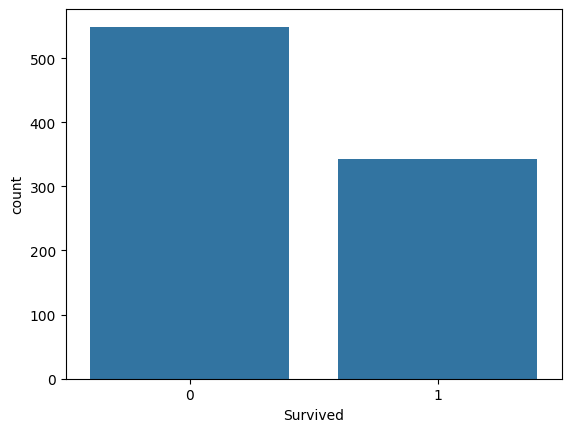

In [20]:
#Univariate Analysis

# Starting with the Survivied Column

sns.countplot(x ='Survived', data = df)

death_percent = round(((df['Survived'].value_counts().values[0]/891) * 100), 1)

print("Out of 891 {} percent people died in the accident".format(death_percent))

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

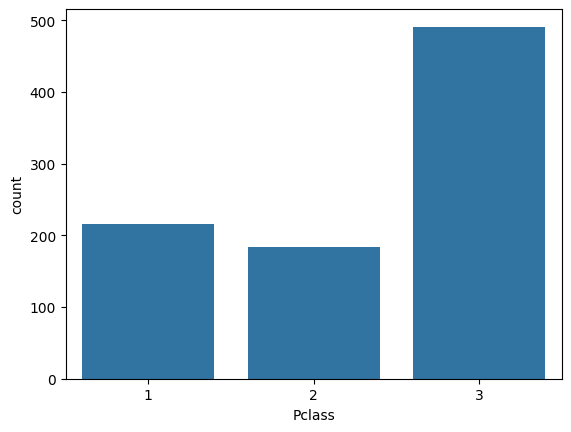

In [21]:
#Pclass column

print((df['Pclass'].value_counts()/891)*100)

sns.countplot(x = 'Pclass', data = df)

# Conclusion : Mostly people are travelling in Pclass 3

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64


<Axes: xlabel='Sex', ylabel='count'>

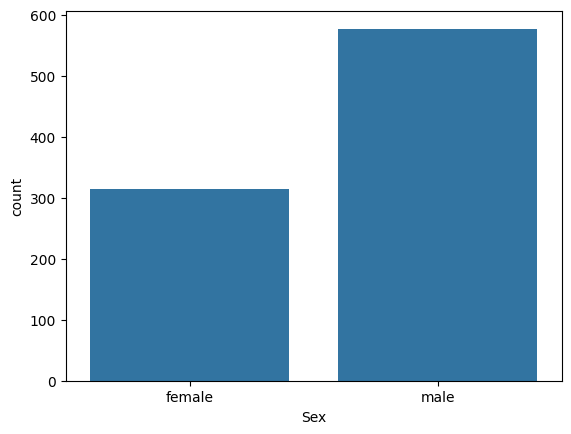

In [22]:
print((df['Sex'].value_counts()/891)*100)

sns.countplot(x = 'Sex', data = df)

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: xlabel='SibSp', ylabel='count'>

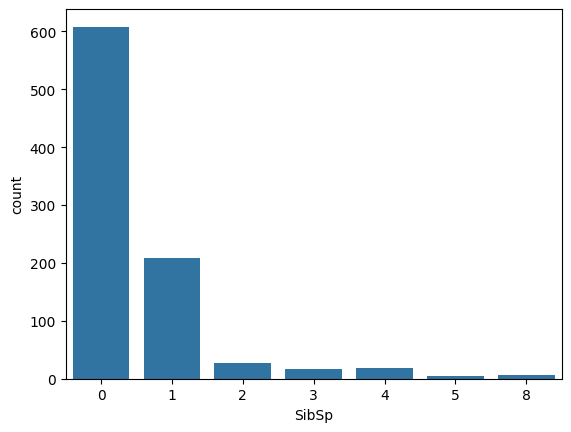

In [23]:
print(df['SibSp'].value_counts())

sns.countplot(x = 'SibSp', data = df)

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


<Axes: xlabel='Parch', ylabel='count'>

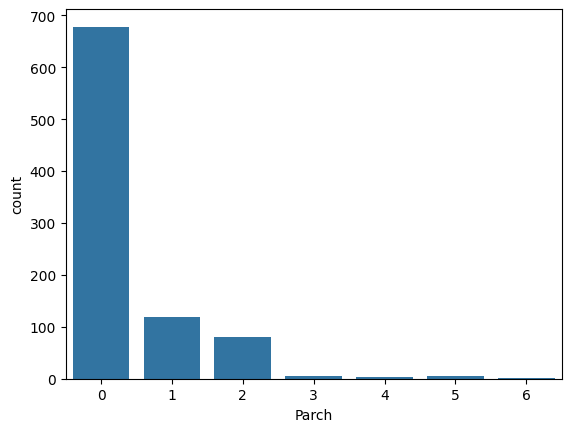

In [24]:
print(df['Parch'].value_counts())

sns.countplot(x = 'Parch', data = df)

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


<Axes: xlabel='Parch', ylabel='count'>

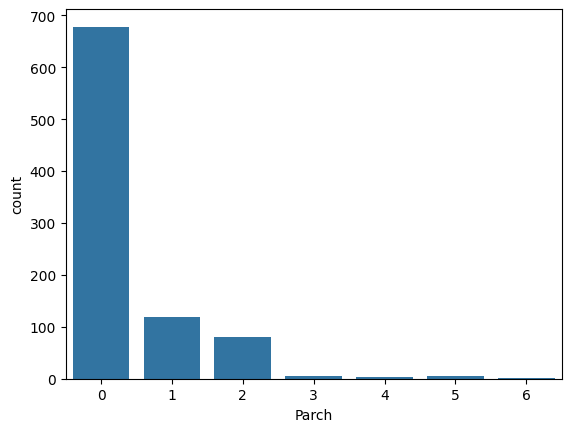

In [25]:
print((df['Parch'].value_counts()/891) * 100)

sns.countplot(x = 'Parch', data = df)

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='Embarked', ylabel='count'>

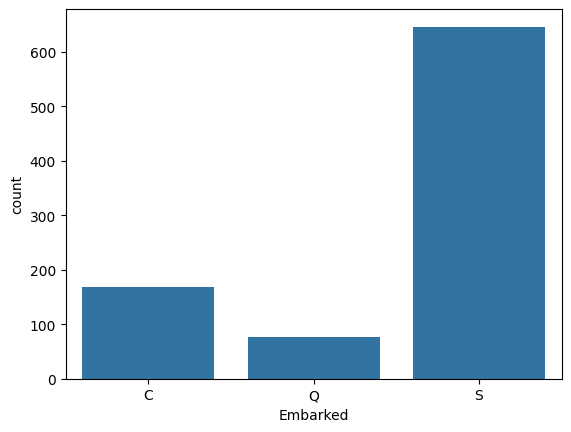

In [26]:
# Cities where people are going to

print((df['Embarked'].value_counts()/891) * 100)

sns.countplot(x = 'Embarked', data = df)


## Progress Update

### Data Cleaning
- Filled missing values in the **Age** column using the mean age.
- Filled missing values in the **Embarked** column using the most frequent value (mode).
- Verified that there were no missing values remaining.
- Changed suitable columns to the **category** data type to reduce memory usage and improve analysis.

### Data Summary
- Generated the five-number statistical summary using `describe()`.
- Reviewed the distribution of numerical features.

### Univariate Analysis

Analyzed individual columns using `countplot()` and percentage calculations.

#### Survived
- Counted the number of passengers who survived and who did not.
- Calculated the survival and death percentages.

#### Passenger Class (Pclass)
- Visualized the distribution of passengers across different classes.
- Calculated the percentage of passengers in each class.

#### Sex
- Compared the number of male and female passengers.
- Calculated their percentages.

#### Siblings/Spouses (SibSp)
- Analyzed how many siblings or spouses each passenger was travelling with.

#### Parents/Children (Parch)
- Analyzed the number of parents or children travelling with each passenger.
- Calculated the percentage distribution.

#### Embarked
- Analyzed the distribution of passengers based on their port of embarkation.
- Calculated the percentage for each embarkation port.

0.45956263424701577
0.9865867453652877


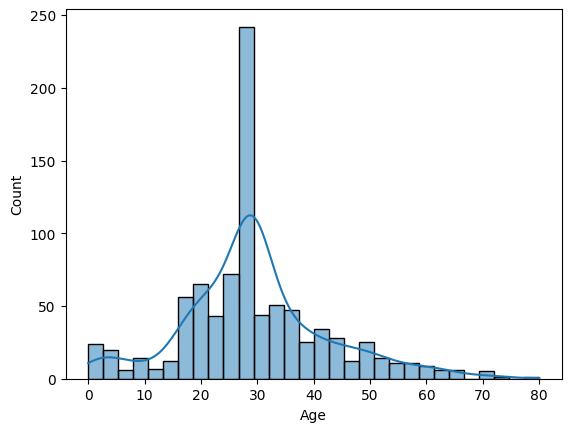

In [36]:
 #Age column
 
sns.histplot(x = 'Age', data = df,kde=True)
print(df['Age'].skew()) 
print(df['Age'].kurt()) 

# skew --> -0.5 to 0.5 can be used as Normal Dist

<Axes: xlabel='Age'>

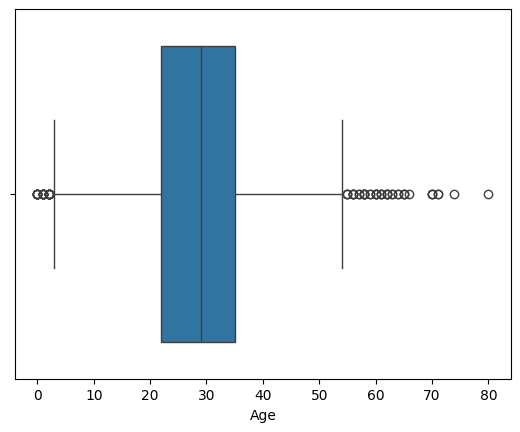

In [37]:
sns.boxplot(x = 'Age', data = df)

In [38]:
# Just out of curiosity

print("People with age in between 60 and 70 are",df[(df['Age']>60) & (df['Age']<70)].shape[0])
print("People with age greater than 70 and 75 are",df[(df['Age' ]>=70) & (df['Age' ] <= 75) ].shape[0])
print("People with age greater than 75 are", df[df[ 'Age' ]>75].shape[0])

print('-'*50)

print("People with age between 0 and 1",df[df['Age']<1].shape[0])

People with age in between 60 and 70 are 15
People with age greater than 70 and 75 are 6
People with age greater than 75 are 1
--------------------------------------------------
People with age between 0 and 1 7



Conclusion

--> For all practical purposes age can be cosidered as normal distribution.

--> Deeper analysis is required for outlier detection

<Axes: xlabel='Fare', ylabel='Count'>

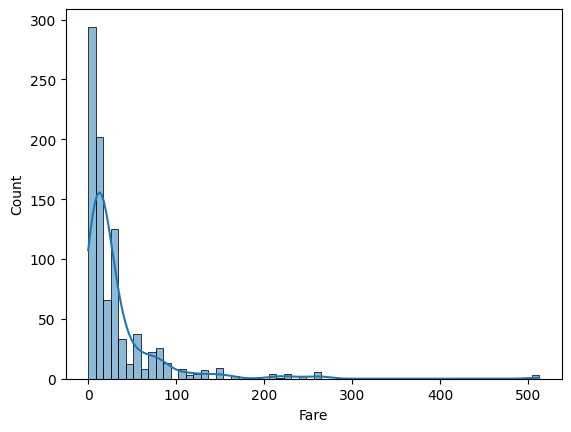

In [39]:
sns.histplot(x = 'Fare', data = df, kde=True)

In [40]:
print(df['Fare'].skew()) 
print(df['Fare'].kurt()) 

4.787316519674893
33.39814088089868


<Axes: xlabel='Fare'>

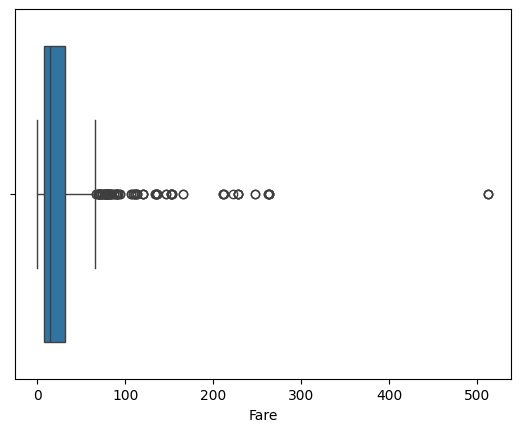

In [41]:
sns.boxplot(x = 'Fare', data = df)

In [42]:
print("People with fare in between $200 and $300",df[(df['Fare' ]>200) & (df['Fare' ]<300) ].shape[0])
print("People with fare in greater than $300", df[df['Fare' ]>300].shape[0])

People with fare in between $200 and $300 17
People with fare in greater than $300 3


Conclusion

--> Highly skewed data, a lot of people had cheaper tickets

--> Outliers are there in the data

Survived,0,1
Pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


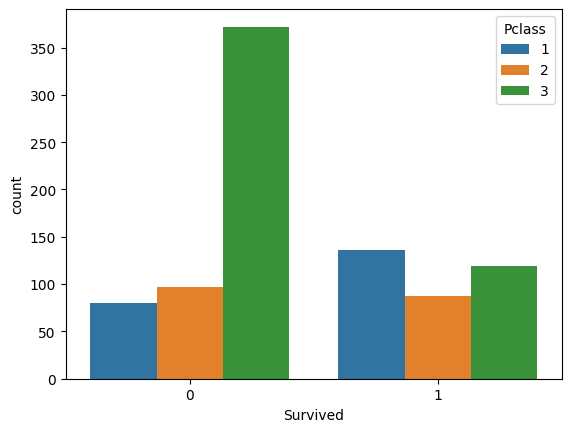

In [ ]:
# Multivariate Analysis
# Survival with Pclass

sns.countplot(x = 'Survived', hue='Pclass', data = df)
pd.crosstab(df['Pclass'], df['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis = 1)

#Travelling in the 3rd class looks scary for real

Sex,female,male
Survived,,
0,25.8,81.1
1,74.2,18.9


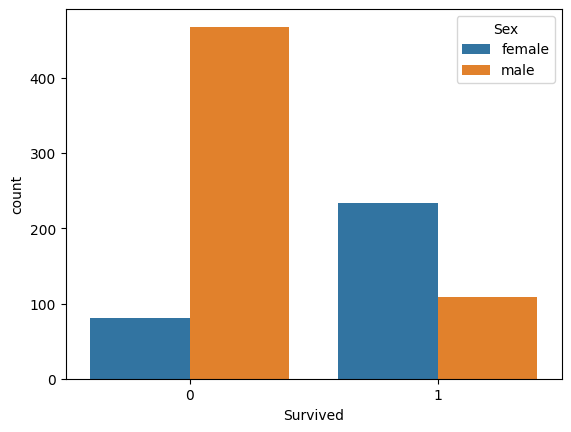

In [ ]:
# Survival with sex

sns.countplot(x = 'Survived', hue = 'Sex', data = df)

pd.crosstab(df['Survived'],df['Sex']).apply(lambda r: round((r/r.sum())*100,1))

#Females had more chance of surviving 

Survived,0,1
Embarked,,
C,44.6,55.4
Q,61.0,39.0
S,66.1,33.9


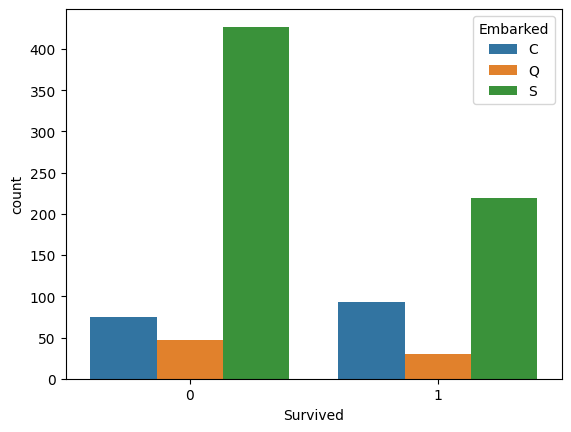

In [55]:
sns.countplot(x = 'Survived', hue = 'Embarked', data = df)

pd.crosstab(df['Embarked'], df['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis = 1)

### Observation

Passengers who embarked from Cherbourg (C) had the highest survival rate (55.4%), while passengers embarking from Southampton (S) had the lowest survival rate (33.9%).

This indicates that survival rates varied across embarkation ports.

<Axes: xlabel='Age', ylabel='Count'>

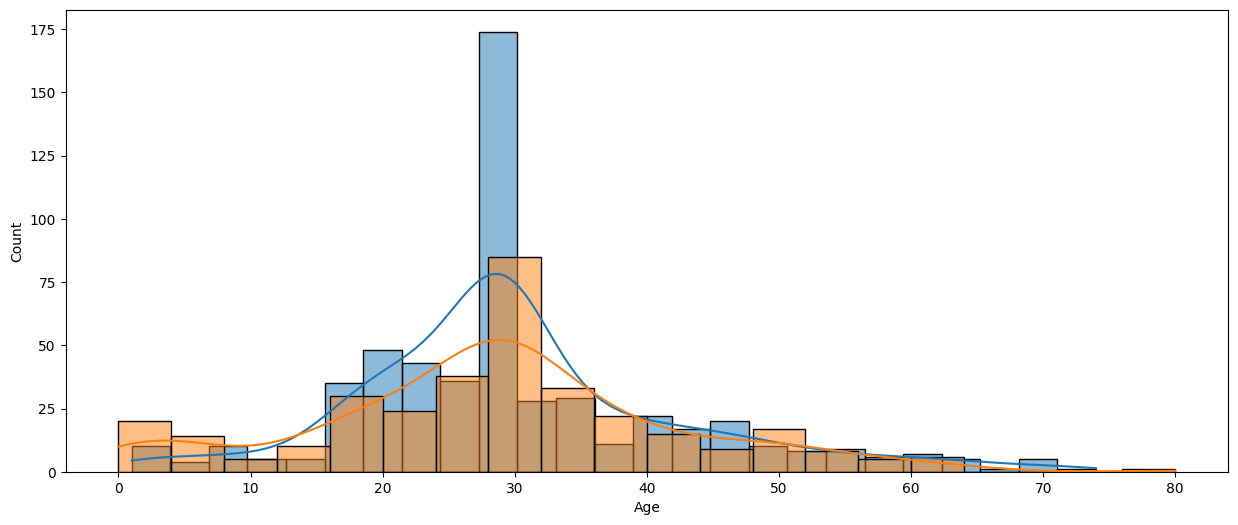

In [ ]:
plt.figure(figsize=(15,6))
sns.histplot(df[df['Survived'] == 0]['Age'], kde=True)
sns.histplot(df[df['Survived'] == 1]['Age'], kde=True)

#Makes sense 

<Axes: xlabel='Fare', ylabel='Count'>

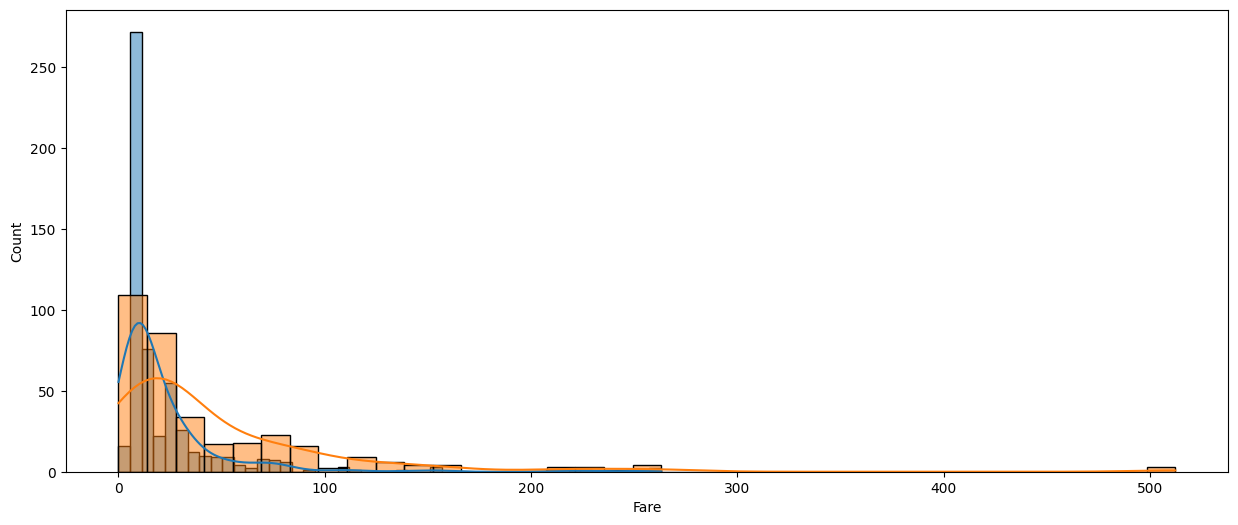

In [ ]:
plt.figure(figsize=(15,6))
sns.histplot(df[df['Survived'] == 0]['Fare'], kde=True)
sns.histplot(df[df['Survived'] == 1]['Fare'], kde=True)

#As the fare increases the chance of living increases

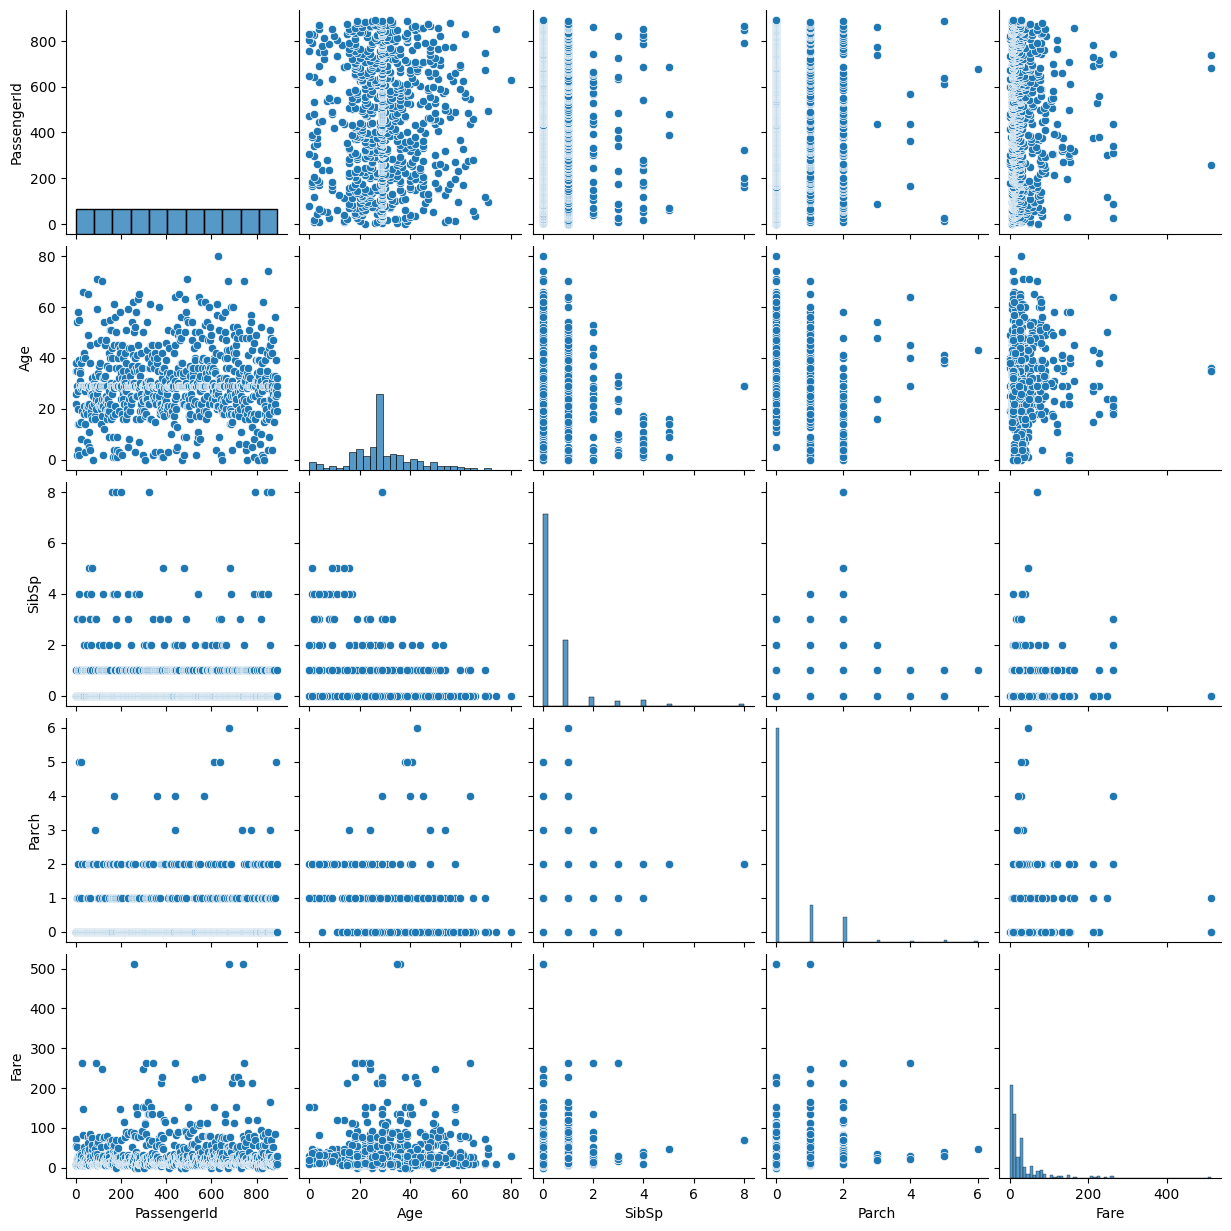

In [59]:
sns.pairplot(df)

<Axes: >

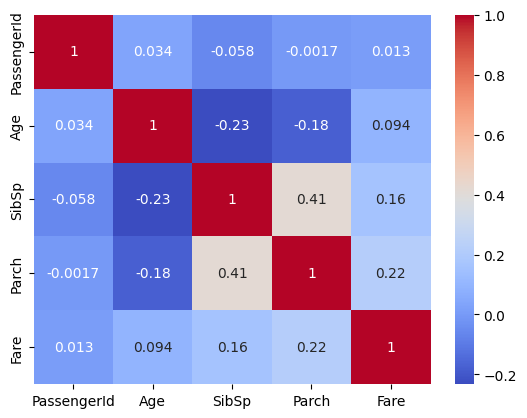

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")

#Parch and fare has high correlation
#SibSp and Parch has high Corr

# Progress Update (Day 2)

## Data Cleaning

Completed the remaining data preprocessing tasks to prepare the dataset for analysis.

### Cleaning Performed

- Removed the **Cabin** column due to a high percentage of missing values.
- Imputed missing values in the **Age** column using an appropriate strategy.
- Filled missing values in the **Embarked** column.
- Updated data types where required for better analysis.
- Verified that the dataset contains no duplicate records.

---

# Exploratory Data Analysis

## Univariate Analysis

Performed detailed analysis of individual features including:

- Survival distribution
- Passenger class (Pclass)
- Gender (Sex)
- Number of siblings/spouses (SibSp)
- Number of parents/children (Parch)
- Port of embarkation (Embarked)
- Age distribution
- Fare distribution

Key statistical measures such as skewness, kurtosis, and boxplots were used to understand data distribution and identify outliers.

---

## Multivariate Analysis

Explored relationships between survival and important passenger characteristics.

Analysis included:

- Survival vs Passenger Class
- Survival vs Gender
- Survival vs Embarkation Port
- Age distribution by survival status
- Fare distribution by survival status

Cross-tabulation was used to calculate survival percentages across different categories, providing better insights than raw counts alone.

---

## Correlation Analysis

- Generated a correlation matrix using numerical features.
- Visualized feature relationships using a heatmap.
- Began identifying variables that have stronger relationships with passenger survival.

---

## Key Learning Outcomes

During this phase of the project, I learned:

- How to choose an appropriate missing value handling strategy.
- When to remove a feature instead of imputing missing values.
- How to interpret skewness, kurtosis, histograms, and boxplots.
- The difference between raw counts and percentage-based comparisons.
- How to use `pd.crosstab()` for categorical analysis.
- How to perform and interpret correlation analysis using a heatmap.